In [7]:
"""Loss fraction vs Bcrit at tmax = 1e-1.

Self-contained: reads data/ relative to this script.
"""
import glob
import os
import numpy as np
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt



In [25]:
FontSize = 22
label_kw = {"fontfamily": "Times New Roman", "fontsize": FontSize}
tick_labelsize = FontSize - 2

plt.rcParams.update(
    {
        "font.family": "Times New Roman",
        "mathtext.fontset": "custom",
        "mathtext.rm": "Times New Roman",
        "mathtext.it": "Times New Roman:italic",
        "mathtext.bf": "Times New Roman:bold",
        "figure.figsize": (6.4, 4.8)
    }
)


# Default axes box in figure coordinates (0–1); tune once, reuse everywhere
AXES_MARGINS = dict(left=0.16, right=0.97, bottom=0.15, top=0.97) # percentages of the figure height/width

plt.rcParams.update(
    {
        "figure.subplot.left": AXES_MARGINS["left"],
        "figure.subplot.right": AXES_MARGINS["right"],
        "figure.subplot.bottom": AXES_MARGINS["bottom"],
        "figure.subplot.top": AXES_MARGINS["top"],
        # optional: spacing for multi-panel figures
        "figure.subplot.wspace": 0.25,
        "figure.subplot.hspace": 0.25,
    }
)


# apply to figures to apply even if using tight_layout
def apply_standard_axes(fig):
    fig.subplots_adjust(**AXES_MARGINS)


In [26]:
# HERE = os.path.dirname(os.path.abspath(__file__))
(path,) = glob.glob(os.path.join("data", "*_loss_fraction_vs_Bcrit.txt"))
d = np.loadtxt(path)
Bcrit = np.linspace(4.5,7.8,40)
print("Bcrit", Bcrit)


Bcrit [4.5        4.58461538 4.66923077 4.75384615 4.83846154 4.92307692
 5.00769231 5.09230769 5.17692308 5.26153846 5.34615385 5.43076923
 5.51538462 5.6        5.68461538 5.76923077 5.85384615 5.93846154
 6.02307692 6.10769231 6.19230769 6.27692308 6.36153846 6.44615385
 6.53076923 6.61538462 6.7        6.78461538 6.86923077 6.95384615
 7.03846154 7.12307692 7.20769231 7.29230769 7.37692308 7.46153846
 7.54615385 7.63076923 7.71538462 7.8       ]


In [27]:
from scipy.interpolate import interp1d
Bcrit_max = 6.19
Bcrit_min = 5.01
loss_data_plt = d[:,-1]
lf_max = interp1d(Bcrit, loss_data_plt)(Bcrit_max)
lf_min = interp1d(Bcrit, loss_data_plt)(Bcrit_min)

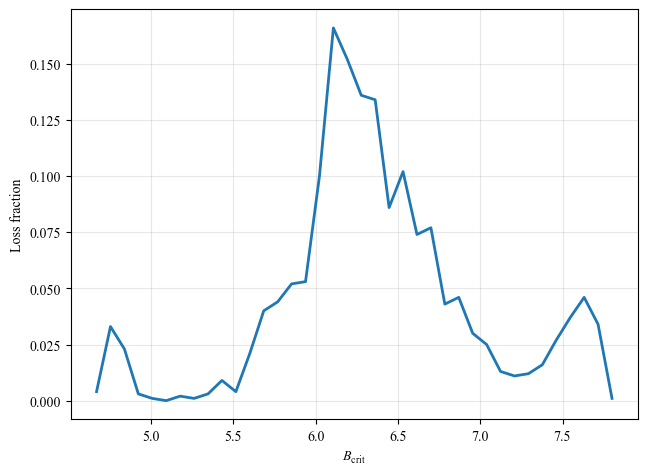

In [28]:
fig, ax = plt.subplots(figsize=(7.0, 5.0))
ax.plot(d[:, 0], d[:, 2], "-", color="tab:blue", lw=2)
ax.set_xlabel(r"$B_{\rm crit}$")
ax.set_ylabel("Loss fraction")
ax.grid(alpha=0.3)
# fig.tight_layout()
out = "loss_frac_vs_Bcrit_tmax_1e-1.png"
# fig.savefig(out, dpi=300)
# print("wrote", out)


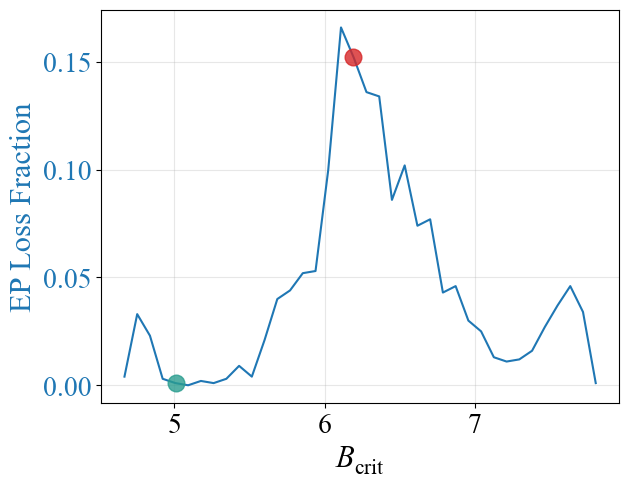

In [29]:
fig, ax_left = plt.subplots()
ax_left.tick_params(axis='x', labelsize=tick_labelsize)

ax_left.plot(Bcrit, d[:, -1], color='tab:blue', label='loss fraction')
ax_left.set_ylabel('EP Loss Fraction', color='tab:blue',**label_kw)
ax_left.tick_params(axis='y', labelcolor='tab:blue', labelsize=tick_labelsize)
ax_left.set_xlabel(r'$B_{\mathrm{crit}}$',**label_kw)
ax_left.grid(True, alpha=0.3)
ax_left.plot(Bcrit_max,lf_max,'o',color='tab:red',markersize=12,alpha=0.8)
ax_left.plot(Bcrit_min,lf_min,'o',color = "#2A9D8F",markersize=12,alpha=0.8)
apply_standard_axes(fig)
plt.savefig('only_loss_frac_vs_Bcrit.pdf', dpi=300)